In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import seaborn as sns
import jax.random as random
import jax.numpy as jnp
import numpy as np
import optax
import os
from dataclasses import dataclass
from typing import List, Optional, Dict, Any, Tuple
import sys
import importlib.util
import re

from shearnet.core.dataset import generate_dataset, split_combined_images
from shearnet.config.config_handler import Config

from flax.training import checkpoints, train_state
from shearnet.utils.metrics import eval_model, eval_ngmix, remove_nan_preds_multi

from shearnet.utils.plot_helpers import (
    plot_residuals, 
    plot_true_vs_predicted, 
    animate_model_epochs
)

from shearnet.utils.notebook_output_system import (
    log_print, save_plot, log_array_stats, experiment_section, get_output_manager
)

In [2]:
@dataclass
class ModelConfig:
    """Configuration for a ShearNet model to compare"""
    name: str  # Display name for plots
    model_dir_prefix: str  # Directory prefix to search for
    color: str  # Color for plots
    marker: str = 'o'  # Marker style for scatter plots
    
    def __post_init__(self):
        """Initialize configuration containers"""
        self.training_config = None
        self.test_config = None

In [3]:
# Define the models you want to compare
model_configs = [
    ModelConfig(
        name="third_validation_test",
        model_dir_prefix="third_validation_test",
        color="blue", 
        marker="s"
    )
]

DEBUG: Current working directory: /home/adfield/ShearNet/notebooks
DEBUG: Found 'notebooks' in current path
DEBUG: Attempting to create directory: /home/adfield/ShearNet/notebooks/out
DEBUG: Directory created/exists: /home/adfield/ShearNet/notebooks/out
DEBUG: Directory is writable: True
DEBUG: Appended to existing output file: /home/adfield/ShearNet/notebooks/out/out.md
ShearNet Output Manager initialized:
  Output directory: /home/adfield/ShearNet/notebooks/out
  Output file: /home/adfield/ShearNet/notebooks/out/out.md
  Directory exists: True
  Can write to directory: True
third_validation_test training stats:
  Final training loss: 0.022562
  Final validation loss: 0.039428
  Best validation loss: 0.035460 at epoch 29
  Total epochs: 49
DEBUG: Attempting to save plot to: /home/adfield/ShearNet/notebooks/out/learning_curves_comparison_20260615_105538.png
SUCCESS: Plot saved to /home/adfield/ShearNet/notebooks/out/learning_curves_comparison_20260615_105538.png (size: 201249 bytes)
![

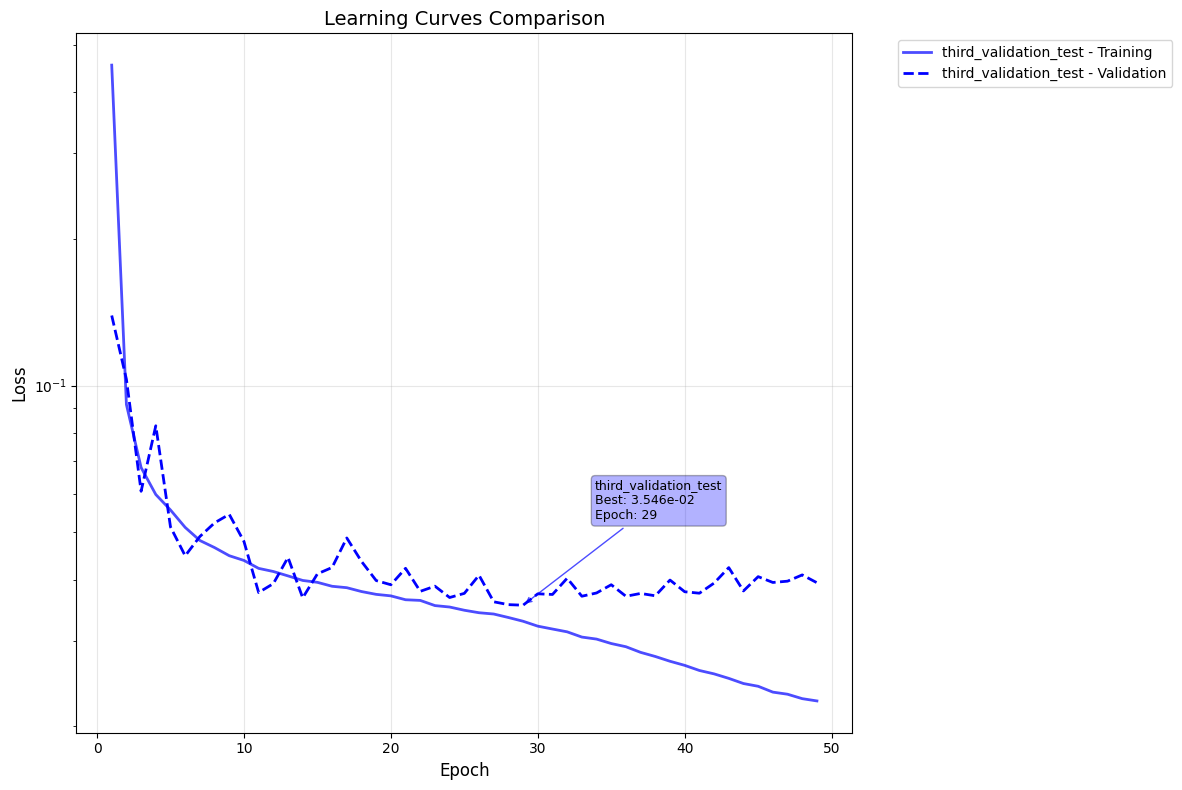

In [4]:
base_data_path = os.getenv('SHEARNET_DATA_PATH', os.path.abspath('.'))
    
plt.figure(figsize=(12, 8))

for config in model_configs:
    # Load loss data for this model
    loss_file = os.path.join(base_data_path, "plots", config.model_dir_prefix, f"{config.model_dir_prefix}_loss.npz")
    
    if os.path.exists(loss_file):
        loss = np.load(loss_file)
        train_loss = loss['train_loss']
        val_loss = loss['val_loss']
        
        epochs = np.arange(1, len(train_loss) + 1)
        
        # Plot with model-specific colors
        plt.plot(epochs, train_loss, color=config.color, linestyle='-', 
                label=f'{config.name} - Training', linewidth=2, alpha=0.7)
        plt.plot(epochs, val_loss, color=config.color, linestyle='--', 
                label=f'{config.name} - Validation', linewidth=2)
        
        # Add annotations for best validation loss
        best_val_epoch = np.argmin(val_loss) + 1
        best_val_loss = np.min(val_loss)
        plt.annotate(f'{config.name}\nBest: {best_val_loss:.3e}\nEpoch: {best_val_epoch}',
                    xy=(best_val_epoch, best_val_loss), 
                    xytext=(best_val_epoch + len(epochs)*0.1, best_val_loss * 1.5),
                    arrowprops=dict(arrowstyle='->', color=config.color, alpha=0.7),
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=config.color, alpha=0.3))
        
        # Log statistics
        log_print(f"{config.name} training stats:")
        log_print(f"  Final training loss: {train_loss[-1]:.6f}")
        log_print(f"  Final validation loss: {val_loss[-1]:.6f}") 
        log_print(f"  Best validation loss: {best_val_loss:.6f} at epoch {best_val_epoch}")
        log_print(f"  Total epochs: {len(train_loss)}")
    else:
        log_print(f"Warning: Loss file not found for {config.name}: {loss_file}")

plt.yscale("log")
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Learning Curves Comparison', fontsize=14)
plt.legend(fontsize=10, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

save_plot("learning_curves_comparison.png")
plt.show()

DEBUG: Attempting to save plot to: /home/adfield/ShearNet/notebooks/out/per_key_val_loss_third_validation_test_20260615_105539.png
SUCCESS: Plot saved to /home/adfield/ShearNet/notebooks/out/per_key_val_loss_third_validation_test_20260615_105539.png (size: 333714 bytes)
![per_key_val_loss_third_validation_test_20260615_105539.png](per_key_val_loss_third_validation_test_20260615_105539.png)


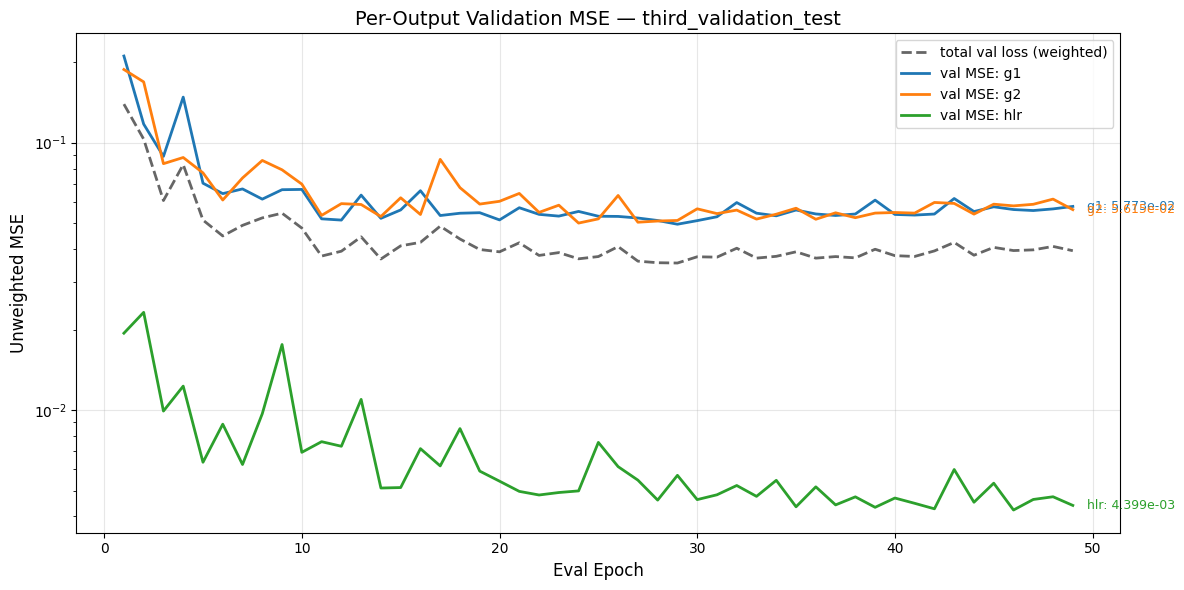


third_validation_test — per-key val MSE at best total-val epoch vs final epoch:
  key      best (ep 29)     final (ep 49)    ratio (final/best)  
  g1       4.9528e-02       5.7734e-02       1.17                
  g2       5.1153e-02       5.6152e-02       1.10                
  hlr      5.6992e-03       4.3988e-03       0.77                


In [5]:
# Per-key validation loss breakdown
for config in model_configs:
    loss_file = os.path.join(base_data_path, "plots", config.model_dir_prefix, f"{config.model_dir_prefix}_loss.npz")
    
    if not os.path.exists(loss_file):
        log_print(f"Warning: Loss file not found for {config.name}: {loss_file}")
        continue

    loss = np.load(loss_file, allow_pickle=True)
    
    # Skip models that were trained before the per-key change
    if "val_loss_per_key" not in loss or "output_keys" not in loss:
        log_print(f"Skipping {config.name}: no per-key data (trained before diagnostic was added)")
        continue

    per_key = loss["val_loss_per_key"]    # shape (n_eval_epochs, n_out)
    keys = list(loss["output_keys"])      # e.g. ['g1', 'g2', 'hlr']
    val_loss = loss["val_loss"]

    n_eval_epochs = len(val_loss)
    epochs = np.arange(1, n_eval_epochs + 1)

    plt.figure(figsize=(12, 6))

    # Plot total val loss
    plt.plot(epochs, val_loss, color="black", linestyle="--", linewidth=2,
             label="total val loss (weighted)", alpha=0.6)

    # Plot each key
    colors_per_key = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]
    for i, k in enumerate(keys):
        c = colors_per_key[i % len(colors_per_key)]
        plt.plot(epochs, per_key[:, i], color=c, linewidth=2, label=f"val MSE: {k}")

        # Annotate the final value
        plt.annotate(f"{k}: {per_key[-1, i]:.3e}",
                     xy=(epochs[-1], per_key[-1, i]),
                     xytext=(10, 0), textcoords="offset points",
                     fontsize=9, color=c, va="center")

    plt.yscale("log")
    plt.xlabel("Eval Epoch", fontsize=12)
    plt.ylabel("Unweighted MSE", fontsize=12)
    plt.title(f"Per-Output Validation MSE — {config.name}", fontsize=14)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    save_plot(f"per_key_val_loss_{config.name}.png")
    plt.show()

    # Print a summary table
    log_print(f"\n{config.name} — per-key val MSE at best total-val epoch vs final epoch:")
    best_epoch_idx = int(np.argmin(val_loss))
    log_print(f"  {'key':<8} {'best (ep {})'.format(best_epoch_idx+1):<16} {'final (ep {})'.format(n_eval_epochs):<16} {'ratio (final/best)':<20}")
    for i, k in enumerate(keys):
        b = per_key[best_epoch_idx, i]
        f = per_key[-1, i]
        log_print(f"  {k:<8} {b:<16.4e} {f:<16.4e} {f/b:<20.2f}")